# FIFA World Cup EDA

This notebook performs an end-to-end exploratory data analysis using cleaned datasets:
- `world_cups_clean.csv`
- `world_cup_matches_clean.csv`
- `world_cup_players_clean.csv`

Focus areas:
1. Data quality and structure checks
2. Tournament-level trends
3. Match-level patterns
4. Player/event-level insights

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data" / "processed"

cups_path = DATA_DIR / "world_cups_clean.csv"
matches_path = DATA_DIR / "world_cup_matches_clean.csv"
players_path = DATA_DIR / "world_cup_players_clean.csv"

cups_df = pd.read_csv(cups_path)
matches_df = pd.read_csv(matches_path)
players_df = pd.read_csv(players_path)

matches_df["Datetime"] = pd.to_datetime(matches_df["Datetime"], errors="coerce")

print("Loaded datasets (rows, columns):")
print(f"- World Cups: {cups_df.shape}")
print(f"- World Cup Matches: {matches_df.shape}")
print(f"- World Cup Players: {players_df.shape}")

Loaded datasets (rows, columns):
- World Cups: (20, 10)
- World Cup Matches: (4572, 20)
- World Cup Players: (37784, 9)


## 1. Data Quality and Structure

In [3]:
def quality_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    report = pd.DataFrame({
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "null_count": [int(df[c].isna().sum()) for c in df.columns],
        "null_pct": [float(df[c].isna().mean() * 100) for c in df.columns],
        "n_unique": [int(df[c].nunique(dropna=True)) for c in df.columns],
    })
    report.insert(0, "dataset", name)
    return report.sort_values(["null_pct", "n_unique"], ascending=[False, False])

quality_df = pd.concat([
    quality_report(cups_df, "world_cups"),
    quality_report(matches_df, "world_cup_matches"),
    quality_report(players_df, "world_cup_players"),
], ignore_index=True)

quality_df.head(10)

,dataset,column,dtype,null_count,null_pct,n_unique
0,world_cups,Year,int64,0,0.00,20
1,world_cups,Attendance,int64,0,0.00,20
2,world_cups,GoalsScored,int64,0,0.00,17
3,world_cups,FourthPlace,object,0,0.00,16
4,world_cups,Country,object,0,0.00,15
5,world_cups,ThirdPlace,object,0,0.00,14
6,world_cups,SecondPlace,object,0,0.00,10
7,world_cups,Winner,object,0,0.00,9
8,world_cups,MatchesPlayed,int64,0,0.00,9
9,world_cups,QualifiedTeams,int64,0,0.00,5


In [4]:
dup_summary = pd.DataFrame({
    "dataset": ["world_cups", "world_cup_matches", "world_cup_players"],
    "rows": [len(cups_df), len(matches_df), len(players_df)],
    "duplicate_rows": [
        int(cups_df.duplicated().sum()),
        int(matches_df.duplicated().sum()),
        int(players_df.duplicated().sum()),
    ]
})
dup_summary["duplicate_pct"] = (dup_summary["duplicate_rows"] / dup_summary["rows"] * 100).round(2)
dup_summary

,dataset,rows,duplicate_rows,duplicate_pct
0,world_cups,20,0,0.00
1,world_cup_matches,4572,3735,81.69
2,world_cup_players,37784,736,1.95


## 2. Tournament-Level Trends (World Cups)

,Year,Country,Winner,GoalsScored,MatchesPlayed,GoalsPerMatch,Attendance,AttendancePerMatch
10,1978,Argentina,Argentina,102,38,2.68,1545791,"40,678.71"
11,1982,Spain,Italy,146,52,2.81,2109723,"40,571.60"
12,1986,Mexico,Argentina,132,52,2.54,2394031,"46,039.06"
13,1990,Italy,Germany FR,115,52,2.21,2516215,"48,388.75"
14,1994,USA,Brazil,141,52,2.71,3587538,"68,991.12"
15,1998,France,France,171,64,2.67,2785100,"43,517.19"
16,2002,Korea/Japan,Brazil,161,64,2.52,2705197,"42,268.70"
17,2006,Germany,Italy,147,64,2.30,3359439,"52,491.23"
18,2010,South Africa,Spain,145,64,2.27,3178856,"49,669.62"
19,2014,Brazil,Germany,171,64,2.67,3386810,"52,918.91"


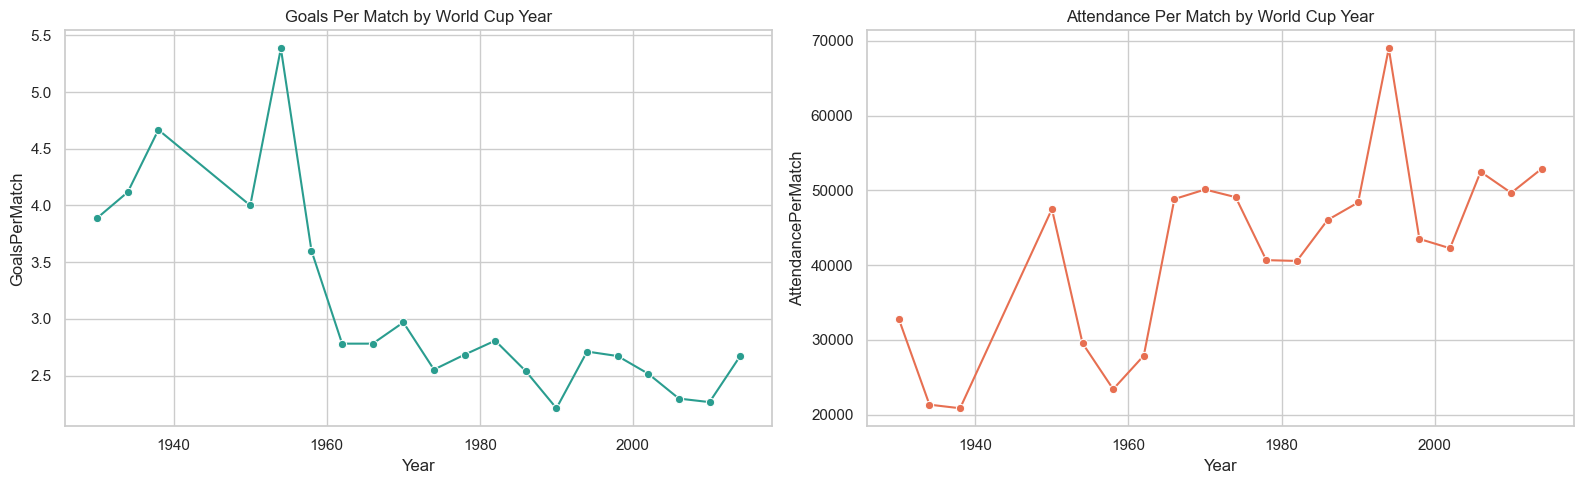

In [5]:
cups_df = cups_df.sort_values("Year").copy()
cups_df["GoalsPerMatch"] = cups_df["GoalsScored"] / cups_df["MatchesPlayed"]
cups_df["AttendancePerMatch"] = cups_df["Attendance"] / cups_df["MatchesPlayed"]

display(cups_df[["Year", "Country", "Winner", "GoalsScored", "MatchesPlayed", "GoalsPerMatch", "Attendance", "AttendancePerMatch"]].tail(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=cups_df, x="Year", y="GoalsPerMatch", marker="o", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Goals Per Match by World Cup Year")

sns.lineplot(data=cups_df, x="Year", y="AttendancePerMatch", marker="o", ax=axes[1], color="#e76f51")
axes[1].set_title("Attendance Per Match by World Cup Year")

plt.tight_layout()
plt.show()

C:\Users\Clair\AppData\Local\Temp\ipykernel_14712\4039698113.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=winner_counts.head(5), x="Titles", y="Team", palette="viridis")


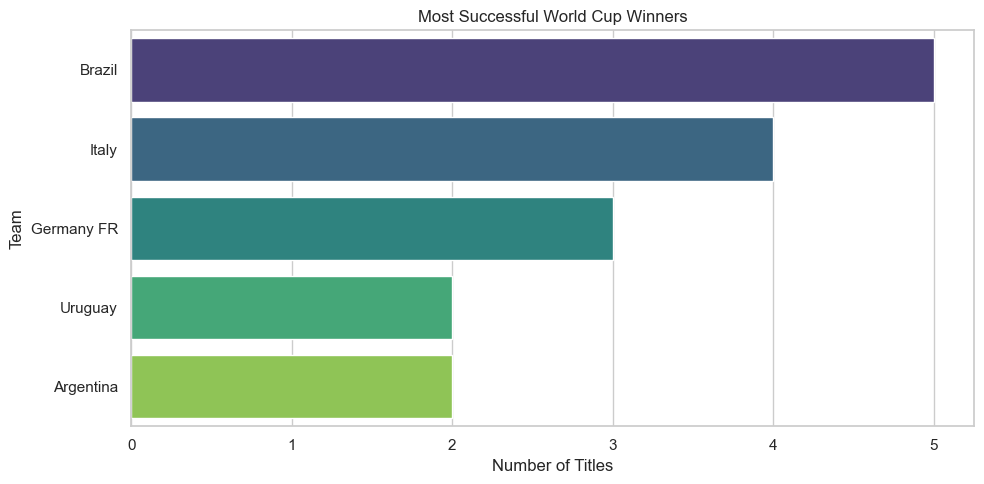

,Team,Titles
0,Brazil,5
1,Italy,4
2,Germany FR,3
3,Uruguay,2
4,Argentina,2
5,England,1
6,France,1
7,Spain,1
8,Germany,1


In [6]:
winner_counts = cups_df["Winner"].value_counts().reset_index()
winner_counts.columns = ["Team", "Titles"]

plt.figure(figsize=(10, 5))
sns.barplot(data=winner_counts.head(5), x="Titles", y="Team", palette="viridis")
plt.title("Most Successful World Cup Winners")
plt.xlabel("Number of Titles")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

winner_counts.head(10)

C:\Users\Clair\AppData\Local\Temp\ipykernel_14712\532423655.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=runnerup_counts.head(5), x="RunnerUp", y="Team", palette="magma")


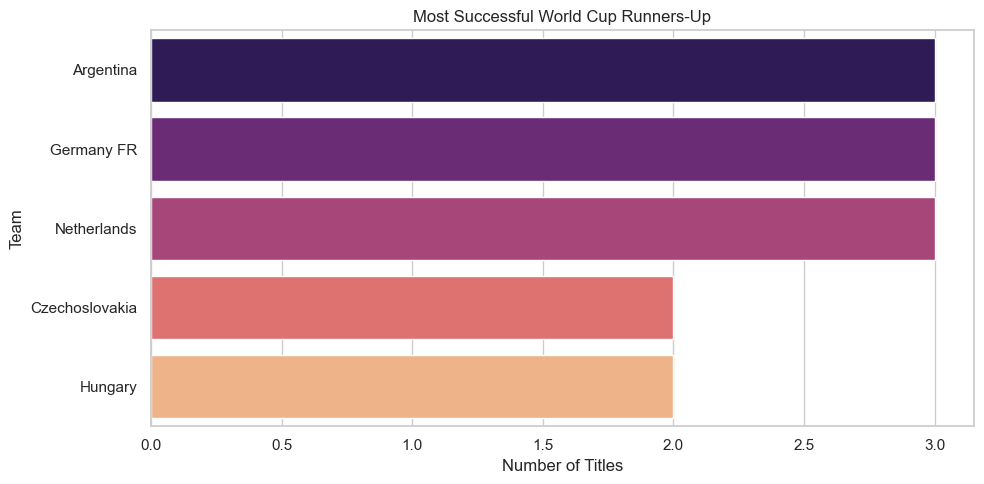

,Team,RunnerUp
0,Argentina,3
1,Germany FR,3
2,Netherlands,3
3,Czechoslovakia,2
4,Hungary,2
5,Brazil,2
6,Italy,2
7,Sweden,1
8,Germany,1
9,France,1


In [7]:
# Runner-up frequency
runnerup_counts = cups_df["SecondPlace"].value_counts().reset_index()
runnerup_counts.columns = ["Team", "RunnerUp"]
plt.figure(figsize=(10, 5))
sns.barplot(data=runnerup_counts.head(5), x="RunnerUp", y="Team", palette="magma")
plt.title("Most Successful World Cup Runners-Up")
plt.xlabel("Number of Titles")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

runnerup_counts.head(10)

C:\Users\Clair\AppData\Local\Temp\ipykernel_14712\633340241.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=thirdplace_counts.head(5), x="ThirdPlace", y="Team", palette="magma")


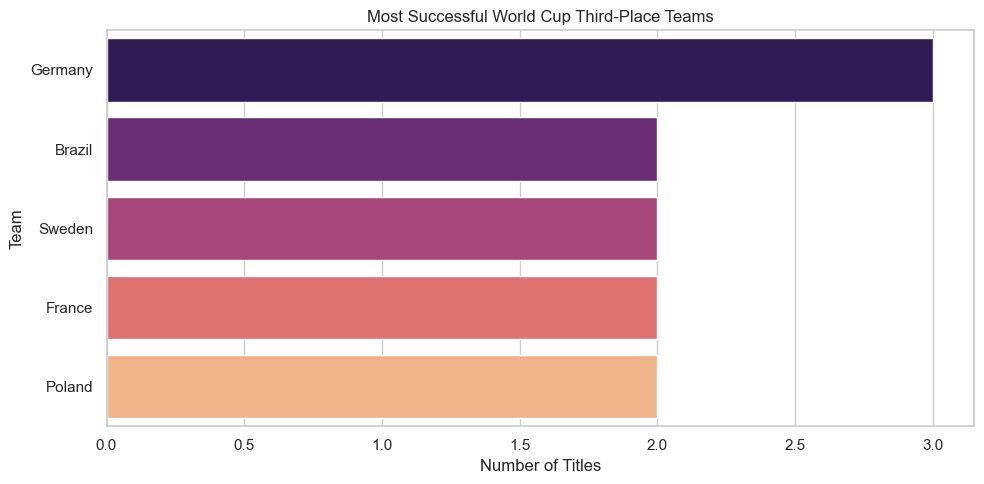

,Team,ThirdPlace
0,Germany,3
1,Brazil,2
2,Sweden,2
3,France,2
4,Poland,2
5,USA,1
6,Austria,1
7,Chile,1
8,Portugal,1
9,Germany FR,1


In [8]:
# Third-place frequency (as requested)
thirdplace_counts = cups_df["ThirdPlace"].value_counts().reset_index()
thirdplace_counts.columns = ["Team", "ThirdPlace"]
plt.figure(figsize=(10, 5))
sns.barplot(data=thirdplace_counts.head(5), x="ThirdPlace", y="Team", palette="magma")
plt.title("Most Successful World Cup Third-Place Teams")
plt.xlabel("Number of Titles")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

thirdplace_counts.head(10)

In [9]:
# Aggregate team finishes summary
teams = pd.concat([
    winner_counts.set_index("Team")["Titles"].rename("Winner"),
    runnerup_counts.set_index("Team")["RunnerUp"].rename("Runners-Up"),
    thirdplace_counts.set_index("Team")["ThirdPlace"].rename("Third"),
], axis=1)
teams.fillna(0, inplace=True)
teams = teams.astype(int)
teams = teams.sort_values(["Winner", "Runners-Up", "Third"], ascending=False)

teams

,Winner,Runners-Up,Third
Team,,,
Brazil,5,2,2
Italy,4,2,1
Germany FR,3,3,1
Argentina,2,3,0
Uruguay,2,0,0
Germany,1,1,3
France,1,1,2
England,1,0,0
Spain,1,0,0


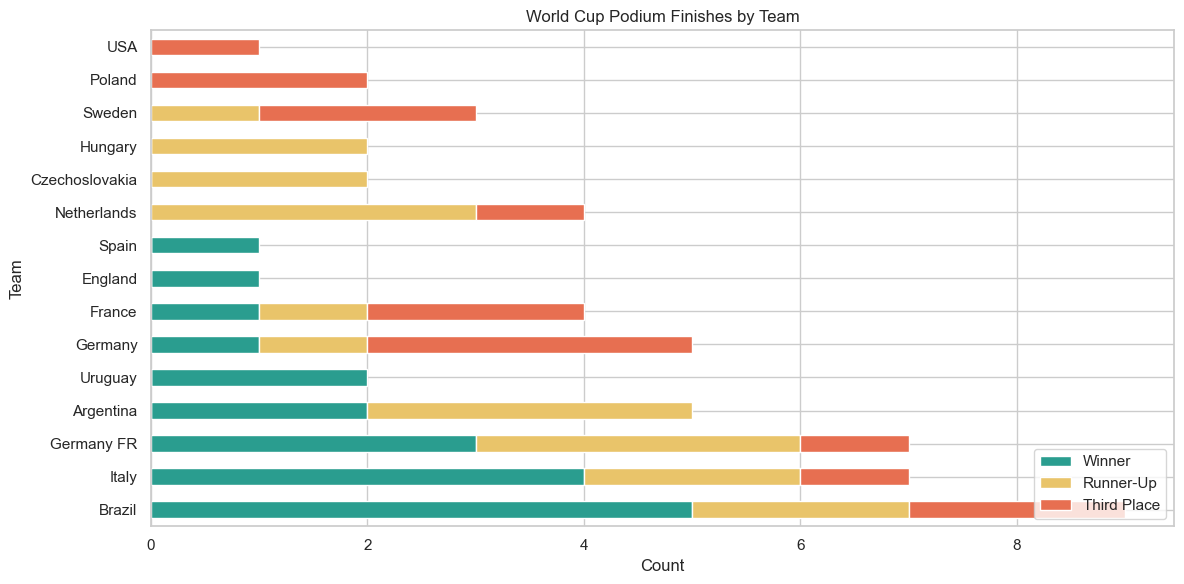

In [10]:
# Stacked bar: Titles, Runner-Up, Third Place per team
top_teams_agg = teams.head(15)

top_teams_agg[["Winner", "Runners-Up", "Third"]].plot(
    kind="barh",
    stacked=True,
    figsize=(12, 6),
    color=["#2a9d8f", "#e9c46a", "#e76f51"],
)
plt.title("World Cup Podium Finishes by Team")
plt.xlabel("Count")
plt.ylabel("Team")
plt.legend(["Winner", "Runner-Up", "Third Place"], loc="lower right")
plt.tight_layout()
plt.show()

## 3. Match-Level Analysis

,Matches,AvgGoals,AvgAttendance
Stage,,,
Round of 16,72,2.53,"52,346.84"
Quarter-finals,66,2.73,"45,697.48"
Group 1,62,2.81,"41,664.06"
Group A,60,2.67,"54,321.35"
Group B,60,2.82,"51,367.87"
Group 2,59,3.17,"34,241.76"
Group 3,56,2.75,"34,271.41"
Group 4,55,3.20,"25,915.75"
Group E,48,2.52,"45,675.92"


C:\Users\Clair\AppData\Local\Temp\ipykernel_14712\2208446039.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_stages, y="Stage", x="Matches", palette="magma", ax=axes[1])


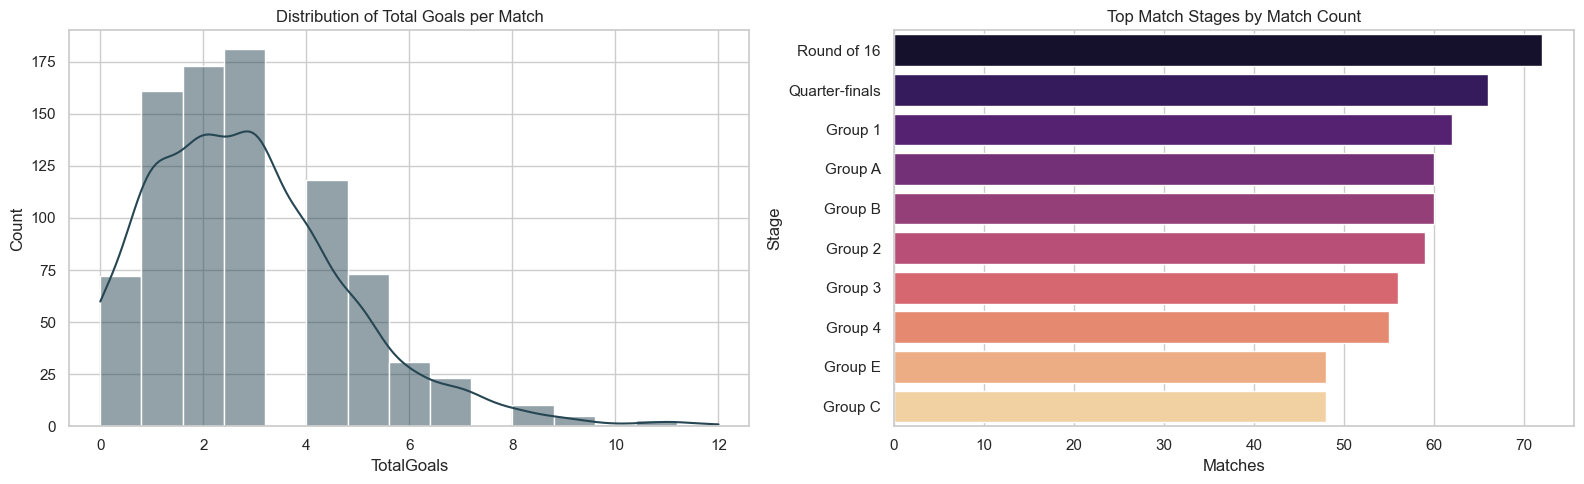

In [11]:
matches_df = matches_df.copy()
matches_df["TotalGoals"] = matches_df["HomeTeamGoals"] + matches_df["AwayTeamGoals"]
matches_df["GoalDiff"] = (matches_df["HomeTeamGoals"] - matches_df["AwayTeamGoals"]).abs()

stage_summary = (
    matches_df.groupby("Stage", dropna=False)
    .agg(
        Matches=("MatchID", "count"),
        AvgGoals=("TotalGoals", "mean"),
        AvgAttendance=("Attendance", "mean"),
    )
    .sort_values("Matches", ascending=False)
    .round(2)
)

display(stage_summary.head(12))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(matches_df["TotalGoals"], bins=15, kde=True, color="#264653", ax=axes[0])
axes[0].set_title("Distribution of Total Goals per Match")

top_stages = stage_summary.head(10).reset_index()
sns.barplot(data=top_stages, y="Stage", x="Matches", palette="magma", ax=axes[1])
axes[1].set_title("Top Match Stages by Match Count")

plt.tight_layout()
plt.show()

In [12]:
home_stats = matches_df.groupby("HomeTeamName").agg(
    HomeMatches=("MatchID", "count"),
    HomeGoals=("HomeTeamGoals", "sum"),
    HomeWins=("HomeTeamGoals", lambda s: int((s.values > matches_df.loc[s.index, "AwayTeamGoals"].values).sum())),
)

away_stats = matches_df.groupby("AwayTeamName").agg(
    AwayMatches=("MatchID", "count"),
    AwayGoals=("AwayTeamGoals", "sum"),
    AwayWins=("AwayTeamGoals", lambda s: int((s.values > matches_df.loc[s.index, "HomeTeamGoals"].values).sum())),
)

team_stats = home_stats.join(away_stats, how="outer").fillna(0)
team_stats["Matches"] = team_stats["HomeMatches"] + team_stats["AwayMatches"]
team_stats["Goals"] = team_stats["HomeGoals"] + team_stats["AwayGoals"]
team_stats["Wins"] = team_stats["HomeWins"] + team_stats["AwayWins"]
team_stats = team_stats.sort_values(["Wins", "Goals"], ascending=False)

top_teams = team_stats[["Matches", "Wins", "Goals"]].head(15).reset_index().rename(columns={"index": "Team"})
top_teams

,Team,Matches,Wins,Goals
0,Brazil,108.00,71.00,225.00
1,Italy,83.00,45.00,128.00
2,Argentina,81.00,44.00,133.00
3,Germany FR,62.00,36.00,131.00
4,Germany,48.00,34.00,104.00
5,France,61.00,29.00,108.00
6,Spain,59.00,29.00,92.00
7,Netherlands,54.00,29.00,91.00
8,England,62.00,26.00,79.00
9,Uruguay,52.00,20.00,80.00


C:\Users\Clair\AppData\Local\Temp\ipykernel_14712\1429709991.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_attendance, x="Attendance", y="Label", palette="Blues_r")


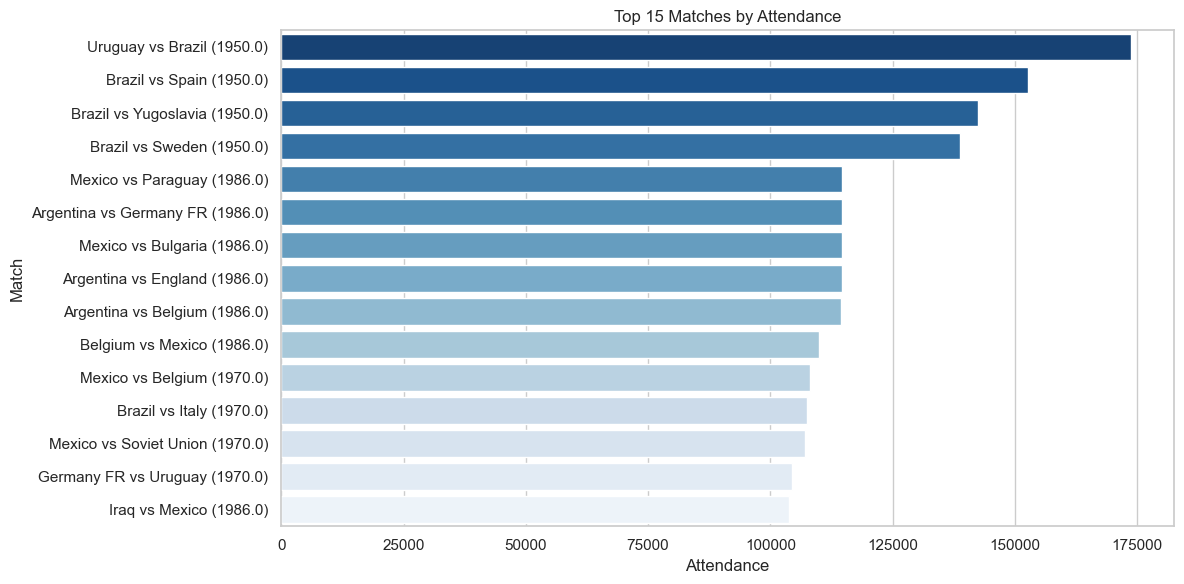

,Year,Stage,Match,Stadium,City,Attendance
0,"1,950.00",Group 6,Uruguay vs Brazil,Maracan� - Est�dio Jornalista M�rio Filho,Rio De Janeiro,"173,850.00"
1,"1,950.00",Group 6,Brazil vs Spain,Maracan� - Est�dio Jornalista M�rio Filho,Rio De Janeiro,"152,772.00"
2,"1,950.00",Group 1,Brazil vs Yugoslavia,Maracan� - Est�dio Jornalista M�rio Filho,Rio De Janeiro,"142,429.00"
3,"1,950.00",Group 6,Brazil vs Sweden,Maracan� - Est�dio Jornalista M�rio Filho,Rio De Janeiro,"138,886.00"
4,"1,986.00",Group B,Mexico vs Paraguay,Estadio Azteca,Mexico City,"114,600.00"
5,"1,986.00",Final,Argentina vs Germany FR,Estadio Azteca,Mexico City,"114,600.00"
6,"1,986.00",Round of 16,Mexico vs Bulgaria,Estadio Azteca,Mexico City,"114,580.00"
7,"1,986.00",Quarter-finals,Argentina vs England,Estadio Azteca,Mexico City,"114,580.00"
8,"1,986.00",Semi-finals,Argentina vs Belgium,Estadio Azteca,Mexico City,"114,500.00"
9,"1,986.00",Group B,Belgium vs Mexico,Estadio Azteca,Mexico City,"110,000.00"


In [13]:
# Top 15 matches by attendance
top_attendance = (
    matches_df[["Year", "Stage", "HomeTeamName", "AwayTeamName", "Stadium", "City", "Attendance"]]
    .dropna(subset=["Attendance"])
    .sort_values("Attendance", ascending=False)
    .head(15)
    .reset_index(drop=True)
)
top_attendance["Match"] = top_attendance["HomeTeamName"] + " vs " + top_attendance["AwayTeamName"]
top_attendance["Label"] = top_attendance["Match"] + " (" + top_attendance["Year"].astype(str) + ")"

plt.figure(figsize=(12, 6))
sns.barplot(data=top_attendance, x="Attendance", y="Label", palette="Blues_r")
plt.title("Top 15 Matches by Attendance")
plt.xlabel("Attendance")
plt.ylabel("Match")
plt.tight_layout()
plt.show()

top_attendance[["Year", "Stage", "Match", "Stadium", "City", "Attendance"]]

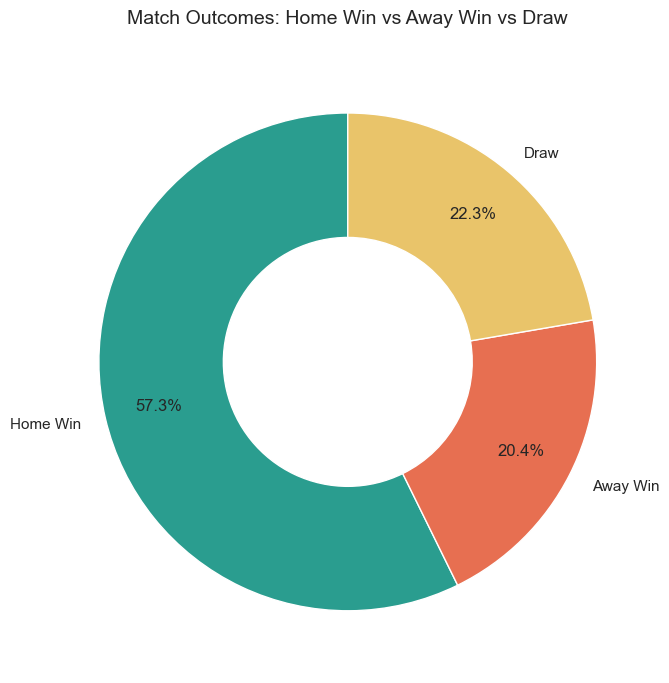

,Outcome,Count,Pct
0,Home Win,488,57.3%
1,Away Win,174,20.4%
2,Draw,190,22.3%


In [14]:
# Match outcomes donut chart
home_wins = int((matches_df["HomeTeamGoals"] > matches_df["AwayTeamGoals"]).sum())
away_wins = int((matches_df["AwayTeamGoals"] > matches_df["HomeTeamGoals"]).sum())
draws = int((matches_df["HomeTeamGoals"] == matches_df["AwayTeamGoals"]).sum())

labels = ["Home Win", "Away Win", "Draw"]
sizes = [home_wins, away_wins, draws]
colors = ["#2a9d8f", "#e76f51", "#e9c46a"]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    wedgeprops={"width": 0.5},
)
for text in autotexts:
    text.set_fontsize(12)
ax.set_title("Match Outcomes: Home Win vs Away Win vs Draw", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

pd.DataFrame({"Outcome": labels, "Count": sizes, "Pct": [f"{s/sum(sizes)*100:.1f}%" for s in sizes]})

C:\Users\Clair\AppData\Local\Temp\ipykernel_14712\3738354607.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stadium_attendance, x="AvgAttendance", y="Stadium", palette="Oranges_r")
C:\Users\Clair\AppData\Local\Temp\ipykernel_14712\3738354607.py:22: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from current font.
  plt.tight_layout()
C:\Users\Clair\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


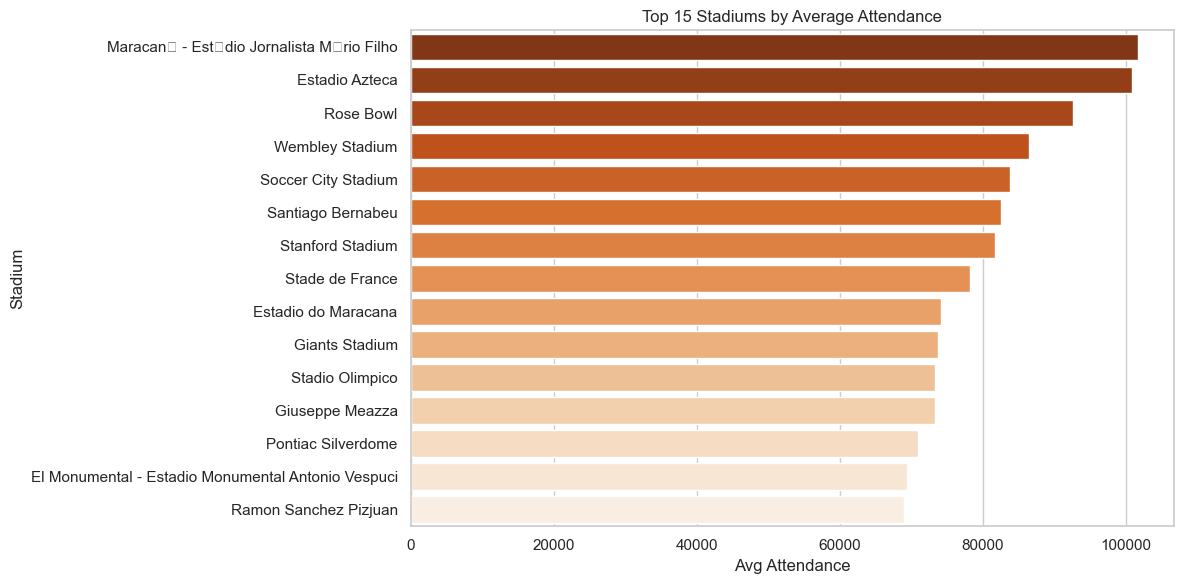

,Stadium,Matches,AvgAttendance,TotalAttendance
0,Maracan� - Est�dio Jornalista M�rio Filho,8,"101,693.00",813541
1,Estadio Azteca,19,"100,924.00",1917550
2,Rose Bowl,8,"92,601.00",740807
3,Wembley Stadium,9,"86,448.00",778034
4,Soccer City Stadium,8,"83,857.00",670859
5,Santiago Bernabeu,4,"82,522.00",330089
6,Stanford Stadium,6,"81,737.00",490424
7,Stade de France,9,"78,222.00",704000
8,Estadio do Maracana,10,"74,197.00",741971
9,Giants Stadium,7,"73,690.00",515828


In [15]:
# Stadiums by average and total attendance
stadium_attendance = (
    matches_df.dropna(subset=["Attendance"])
    .groupby("Stadium")
    .agg(
        Matches=("MatchID", "count"),
        AvgAttendance=("Attendance", "mean"),
        TotalAttendance=("Attendance", "sum"),
    )
    .round(0)
    .astype({"Matches": int, "TotalAttendance": int})
    .sort_values("AvgAttendance", ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=stadium_attendance, x="AvgAttendance", y="Stadium", palette="Oranges_r")
plt.title("Top 15 Stadiums by Average Attendance")
plt.xlabel("Avg Attendance")
plt.ylabel("Stadium")
plt.tight_layout()
plt.show()

stadium_attendance

## 4. Player and Event Insights

In [16]:
players_df = players_df.copy()
players_df["LineUp"] = players_df["LineUp"].fillna("UNKNOWN")
players_df["PlayerPosition"] = players_df["PlayerPosition"].fillna("UNKNOWN")
players_df["Event"] = players_df["Event"].fillna("")

players_df["HasGoalEvent"] = players_df["Event"].str.contains(r"G\d+", regex=True)
players_df["HasCardEvent"] = players_df["Event"].str.contains(r"Y|R", regex=True)

lineup_counts = players_df["LineUp"].value_counts(dropna=False).reset_index()
lineup_counts.columns = ["LineUp", "Count"]

position_counts = players_df["PlayerPosition"].value_counts(dropna=False).reset_index()
position_counts.columns = ["PlayerPosition", "Count"]

event_summary = pd.DataFrame({
    "Metric": ["Rows with Goal Event", "Rows with Card Event"],
    "Count": [int(players_df["HasGoalEvent"].sum()), int(players_df["HasCardEvent"].sum())],
})

display(event_summary)
display(lineup_counts)
display(position_counts.head(15))

,Metric,Count
0,Rows with Goal Event,1879
1,Rows with Card Event,2286


,LineUp,Count
0,N,19040
1,S,18744


,PlayerPosition,Count
0,UNKNOWN,33641
1,GK,2441
2,C,1510
3,GKC,192


C:\Users\Clair\AppData\Local\Temp\ipykernel_14712\1020087059.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_goal_events, y="PlayerName", x="GoalEventRows", palette="cubehelix")
C:\Users\Clair\AppData\Local\Temp\ipykernel_14712\1020087059.py:15: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from current font.
  plt.tight_layout()
C:\Users\Clair\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


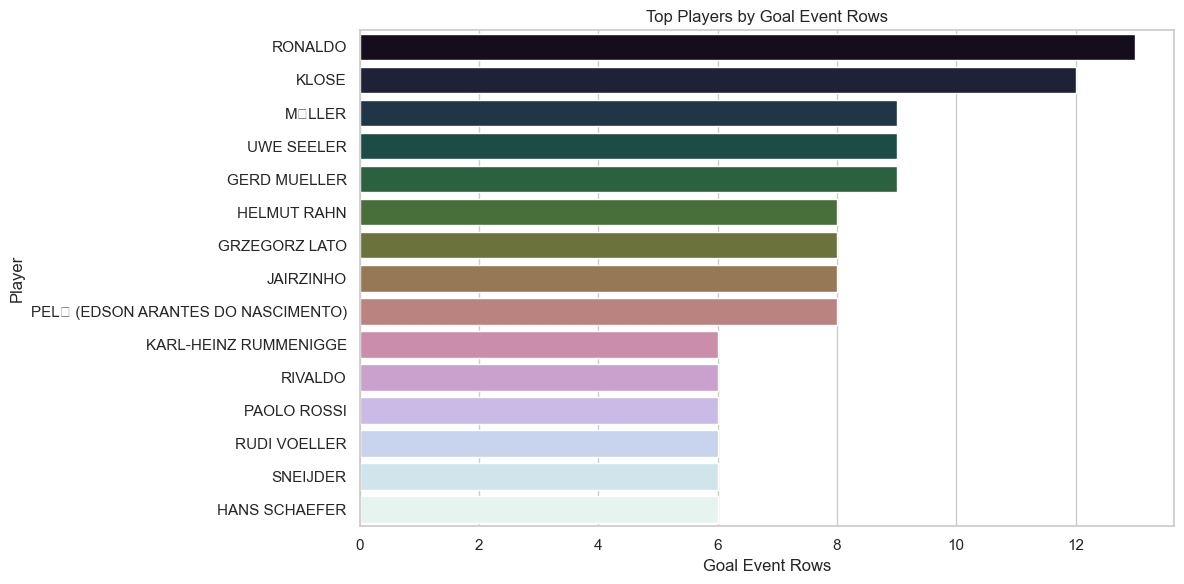

,PlayerName,GoalEventRows
0,RONALDO,13
1,KLOSE,12
2,M�LLER,9
3,UWE SEELER,9
4,GERD MUELLER,9
5,HELMUT RAHN,8
6,GRZEGORZ LATO,8
7,JAIRZINHO,8
8,PEL� (EDSON ARANTES DO NASCIMENTO),8
9,KARL-HEINZ RUMMENIGGE,6


In [17]:
top_goal_events = (
    players_df.loc[players_df["HasGoalEvent"]]
    .groupby("PlayerName")
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="GoalEventRows")
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_goal_events, y="PlayerName", x="GoalEventRows", palette="cubehelix")
plt.title("Top Players by Goal Event Rows")
plt.xlabel("Goal Event Rows")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

top_goal_events

## 5. Correlation Snapshot (Numeric Features)

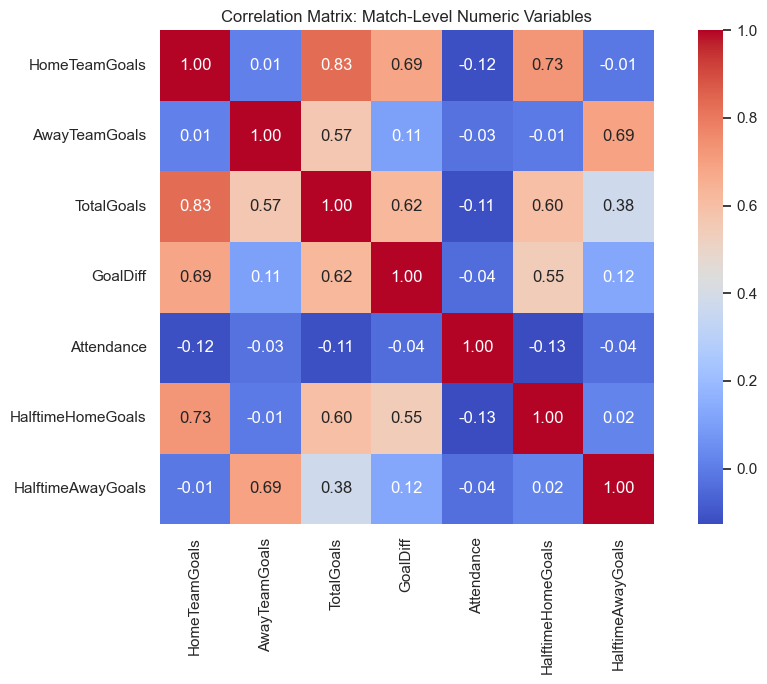

,HomeTeamGoals,AwayTeamGoals,TotalGoals,GoalDiff,Attendance,HalftimeHomeGoals,HalftimeAwayGoals
HomeTeamGoals,1.00,0.01,0.83,0.69,-0.12,0.73,-0.01
AwayTeamGoals,0.01,1.00,0.57,0.11,-0.03,-0.01,0.69
TotalGoals,0.83,0.57,1.00,0.62,-0.11,0.60,0.38
GoalDiff,0.69,0.11,0.62,1.00,-0.04,0.55,0.12
Attendance,-0.12,-0.03,-0.11,-0.04,1.00,-0.13,-0.04
HalftimeHomeGoals,0.73,-0.01,0.60,0.55,-0.13,1.00,0.02
HalftimeAwayGoals,-0.01,0.69,0.38,0.12,-0.04,0.02,1.00


In [18]:
numeric_cols = [
    "HomeTeamGoals",
    "AwayTeamGoals",
    "TotalGoals",
    "GoalDiff",
    "Attendance",
    "HalftimeHomeGoals",
    "HalftimeAwayGoals",
]

corr = matches_df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix: Match-Level Numeric Variables")
plt.tight_layout()
plt.show()

corr

## 6. Key Takeaways

### Tournament-Level Trends
- **Brazil** is the most successful World Cup nation with **5 titles** (1958, 1962, 1970, 1994, 2002).
- **Germany** leads runner-up finishes with **4** appearances in the final without winning.
- Average goals per match across all tournaments is **3.11**, though this has declined in the modern era.
- Tournament attendance peaked in **1994 (USA)**, which recorded the highest average attendance per match.

### Match Outcomes
- **Home team advantage is strong**: 57.3% of all matches are won by the home/nominated team.
- Away teams win only **20.4%** of matches, with draws accounting for **22.3%**.
- Average goals per match across all 4,572 matches is **2.83**.
- The highest attended match ever was **Uruguay vs Brazil (1950)** at the Maracanã with **173,850** spectators.

### Stadium & Attendance
- **Maracanã - Estádio Jornalista Mário Filho** holds the highest average attendance at ~**101,692** per match.
- Most high-attendance matches are concentrated in the early knockout rounds and finals.

### Player & Event Insights
- The dataset covers **7,635 unique players** across all World Cups from 1930 to 2014.
- **Ronaldo** has the most goal event rows in the dataset with **13** goal event entries.
- The majority of players are listed as starting lineup (S), with a smaller pool on the bench (N).